##  개인정보 제공 동의의 계층적 조건: 객관적 경제 조건과 주관적 경제 인식의 비교

<이론적 배경>  
가설 1 ->    
가설 2 ->  프라이버시 자기효능감 그리고 지식격차 Privacy, Security, and Digital Inequality 논문  
가설 3 -> 현재 편향 연구 (또는 Data Poverty 논문)  
가설 4 ->  Does subjective social status predict health and change in health status better than objective status?와   


### 가설

본 연구는 개인정보 제공 동의(`GIVEPIFR_R`)에 영향을 미치는 경제적 요인을 **객관적 경제 조건**과 **주관적 경제상태 평가**로 구분한다. 객관적 경제 조건은 월평균 가구소득의 로그값인 `log_INCOM0`으로 측정하고, 주관적 경제상태 평가는 `RANK`(주관적 계층의식), `SATFIN_R`(가계상태 만족도)로 측정한다. `GIVEPIFR_R`은 원척도 `GIVEPIFR`을 역코딩한 변수이므로, 값이 높을수록 할인이나 무료상품을 받기 위해 개인정보를 제공하는 데 더 동의한다는 의미이다.

본 연구는 다음과 같은 연구가설을 설정한다.

**가설 1.** 객관적 경제 조건인 월평균 가구소득(`log_INCOM0`)이 증가하면, 할인이나 무료상품을 위한 개인정보 제공 동의(`GIVEPIFR_R`)는 감소할 것이다. 

**가설 2.** 주관적 계층의식(`RANK`)이 증가하면, 할인이나 무료상품을 위한 개인정보 제공 동의(`GIVEPIFR_R`)는 증가할 것이다. 

**가설 3.** 현재 가계상태 만족도(`SATFIN_R`)가 증가하면, 할인이나 무료상품을 위한 개인정보 제공 동의(`GIVEPIFR_R`)는 감소할 것이다.

**가설 4.** 주관적 계층의식(`RANK`)과 현재 가계상태 만족도(`SATFIN_R`)를 동시에 고려할 때, `RANK`가 증가하면 개인정보 제공 동의(`GIVEPIFR_R`)는 증가하고, `SATFIN_R`이 증가하면 개인정보 제공 동의(`GIVEPIFR_R`)는 감소할 것이다.

**가설 5.** 객관적 경제 조건(`log_INCOM0`)과 주관적 경제상태 평가(`RANK`, `SATFIN_R`)를 동시에 고려할 때, 개인정보 제공 동의(`GIVEPIFR_R`)는 객관적 소득보다 주관적 경제상태 평가와 더 밀접하게 관련될 것이다. 구체적으로 `RANK`가 증가하면 개인정보 제공 동의는 증가하고, `SATFIN_R`이 증가하면 개인정보 제공 동의는 감소할 것이다.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from IPython.display import display
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from patsy import dmatrices
from statsmodels.stats.outliers_influence import variance_inflation_factor

## 1. 데이터 불러오기

In [2]:
DATA_PATH = Path(r"/home/pck/data_jour/sda_Team Project_/adt_2025_drop_0509.csv")
df_raw = pd.read_csv(DATA_PATH)

print(df_raw.shape)
display(df_raw.head())

(1211, 455)


,YEAR,RESPID,YRRESPID,FINALWT,SEX,AGE,MARITAL,EMPLY,WHYNOE,EDUC,...,HHWHYNOE,HHDNO,HOMPOP,SEPAPOP,UNRELAT,REGION,URBAN,SAMPLEAB,INTDATM,INTDATD
0,2025.0,101.0,202500101.0,1.349140,1.0,44.0,1.0,1.0,-1.0,4.0,...,-1.0,11.0,3.0,0.0,0.0,1.0,1.0,1.0,4.0,6.0
1,2025.0,102.0,202500102.0,0.719461,2.0,62.0,1.0,2.0,3.0,3.0,...,-1.0,2.0,2.0,0.0,0.0,1.0,1.0,2.0,4.0,6.0
2,2025.0,103.0,202500103.0,0.572766,2.0,50.0,1.0,2.0,18.0,3.0,...,-1.0,4.0,3.0,0.0,0.0,1.0,1.0,2.0,4.0,7.0
3,2025.0,104.0,202500104.0,1.093403,1.0,62.0,1.0,1.0,-1.0,3.0,...,-1.0,10.0,2.0,0.0,0.0,1.0,1.0,2.0,5.0,25.0
4,2025.0,105.0,202500105.0,1.093403,1.0,74.0,1.0,2.0,19.0,2.0,...,19.0,12.0,2.0,0.0,0.0,1.0,1.0,2.0,4.0,8.0


## 2. 분석 변수 지정

분석에 사용할 핵심 변수를 지정한다. 


In [3]:
analysis_vars_raw = [
    "GIVEPIFR",
    "INCOM0", "RANK", "SATFIN",
    "AGE", "SEX", "EDUC", "ABLITINF", "TECHHARM",
    "FINALWT",
]

missing = [v for v in analysis_vars_raw if v not in df_raw.columns]
if missing:
    raise ValueError(f"데이터에 없는 변수: {missing}")

display(df_raw[analysis_vars_raw].describe().T)


,count,mean,std,min,25%,50%,75%,max
GIVEPIFR,1211.0,3.507019,1.121057,-8.000000,3.000000,4.00000,4.000000,5.000000
INCOM0,1211.0,448.386457,407.973516,-8.000000,216.000000,400.00000,600.000000,9000.000000
RANK,1211.0,5.065235,1.498717,1.000000,4.000000,5.00000,6.000000,10.000000
SATFIN,1211.0,3.182494,0.886384,1.000000,3.000000,3.00000,4.000000,5.000000
AGE,1211.0,52.611891,15.651251,18.000000,40.000000,54.00000,64.000000,93.000000
SEX,1211.0,1.610239,0.487897,1.000000,1.000000,2.00000,2.000000,2.000000
EDUC,1211.0,3.469860,1.483142,-8.000000,3.000000,3.00000,5.000000,8.000000
ABLITINF,1211.0,2.347647,1.545626,-8.000000,2.000000,2.00000,3.000000,5.000000
TECHHARM,1211.0,3.321222,0.988381,-8.000000,3.000000,3.00000,4.000000,5.000000
FINALWT,1211.0,1.000000,0.611764,0.286383,0.636851,0.87153,1.256653,5.287165


## 3. 데이터 전처리

- `-8`은 공통 결측 코드로 처리한다.
- `ABLITINF`의 `-1`은 비해당으로 보고 결측 처리한다.
- `GIVEPIFR`, `SATFIN`, `ABLITINF`, `TECHHARM`은 분석 방향에 맞게 역코딩한다.
- `INCOM0`는 `log_INCOM0 = log(INCOM0 + 1)`로 변환한다.


### `FINALWT`와 WLS 사용

`FINALWT`는 KGSS에서 제공하는 최종 표본가중치이다. 표본조사에서는 조사 표본이 모집단의 성별, 연령, 지역 등 분포와 완전히 일치하지 않을 수 있으므로, 각 응답자가 모집단에서 어느 정도의 대표성을 갖는지를 보정하기 위해 가중치를 사용한다. 
> kgss 공식 홈페이지 설명: '모든 연도에 적용할 가중치 변수는 가구에서 적격한 성인가구원 추출할 확률과 성별/연령/지역/도시(농촌)을 고려하여 만든 FINALWT 입니다.' (링크: https://kgss.skku.edu/kgss/faq.do#a )

본 분석에서는 `FINALWT`를 가중치로 사용한 WLS(Weighted Least Squares)를 적용한다. WLS는 모든 응답자를 동일한 비중으로 취급하는 OLS와 달리, 가중치가 큰 응답자는 더 큰 비중으로, 가중치가 작은 응답자는 더 작은 비중으로 반영한다. 따라서 본 연구의 WLS 결과는 KGSS의 표본가중치를 반영한 회귀분석 결과로 해석한다.
> 즉, 2025년 표본 자체가 모집단을 완벽히 반영하는 표본이 아닐 수 있기 때문에, 표본의 모집단 대표성을 보정하는 측면에서 사용한다. 


In [4]:
df = df_raw[analysis_vars_raw].copy()

# FINALWT는 이후 WLS 회귀분석에서 표본가중치로 사용한다.

# 공통 결측 코드 처리
for col in analysis_vars_raw:
    df[col] = df[col].replace(-8, np.nan)

# ABLITINF의 -1은 비해당으로 보고 결측 처리
df["ABLITINF"] = df["ABLITINF"].replace(-1, np.nan)

# 종속변수 개인정보 제공 태도 역코딩: 원척도 1=매우 동의, 5=매우 반대
# 분석척도는 1=매우 반대, 5=매우 동의
df["GIVEPIFR_R"] = np.where(df["GIVEPIFR"].isin([1, 2, 3, 4, 5]), 6 - df["GIVEPIFR"], np.nan)

# 독립변수/통제변수 역코딩
# SATFIN_R: 1=매우 불만족, 5=매우 만족
# ABLITINF_R: 1=매우 낮음, 5=매우 높음
for v in ["SATFIN", "ABLITINF"]:
    df[f"{v}_R"] = np.where(df[v].isin([1, 2, 3, 4, 5]), 6 - df[v], np.nan)

# TECHHARM_R: 값이 높을수록 기술위험 인식이 높도록 역코딩
df["TECHHARM_R"] = np.where(df["TECHHARM"].isin([1, 2, 3, 4, 5]), 6 - df["TECHHARM"], np.nan)

# INCOM0 변수 로그 변환
df["log_INCOM0"] = np.log1p(df["INCOM0"].where(df["INCOM0"] >= 0, np.nan))

# EDUC -> EDUC_GROUP
# 고졸 이하: 0=무학, 1=초등학교, 2=중학교, 3=고등학교, 8=서당한학 / 2년제 대학: 4=전문대학 / 4년제 대학: 5=대학교 / 대학원 이상: 6=대학원 석사, 7=대학원 박사
educ_categories = ["고졸 이하", "2년제 대학", "4년제 대학", "대학원 이상"]
df["EDUC_GROUP"] = pd.Series(pd.NA, index=df.index, dtype="object")
df.loc[df["EDUC"].isin([0, 1, 2, 3, 8]), "EDUC_GROUP"] = "고졸 이하"
df.loc[df["EDUC"].eq(4), "EDUC_GROUP"] = "2년제 대학"
df.loc[df["EDUC"].eq(5), "EDUC_GROUP"] = "4년제 대학"
df.loc[df["EDUC"].isin([6, 7]), "EDUC_GROUP"] = "대학원 이상"
df["EDUC_GROUP"] = pd.Categorical(df["EDUC_GROUP"], categories=educ_categories, ordered=True)


display(df.head())
display(df[["GIVEPIFR", "GIVEPIFR_R", "SATFIN_R", "ABLITINF_R", "log_INCOM0", "EDUC", "EDUC_GROUP", "TECHHARM_R"]].head())
display(df.isna().sum())


,GIVEPIFR,INCOM0,RANK,SATFIN,AGE,SEX,EDUC,ABLITINF,TECHHARM,FINALWT,GIVEPIFR_R,SATFIN_R,ABLITINF_R,TECHHARM_R,log_INCOM0,EDUC_GROUP
0,3.0,600.0,4.0,4.0,44.0,1.0,4.0,2.0,2.0,1.349140,3.0,2.0,4.0,4.0,6.398595,2년제 대학
1,2.0,280.0,4.0,4.0,62.0,2.0,3.0,2.0,4.0,0.719461,4.0,2.0,4.0,2.0,5.638355,고졸 이하
2,3.0,250.0,5.0,3.0,50.0,2.0,3.0,2.0,2.0,0.572766,3.0,3.0,4.0,4.0,5.525453,고졸 이하
3,2.0,NaN,2.0,4.0,62.0,1.0,3.0,2.0,3.0,1.093403,4.0,2.0,4.0,3.0,NaN,고졸 이하
4,4.0,320.0,3.0,5.0,74.0,1.0,2.0,3.0,3.0,1.093403,2.0,1.0,3.0,3.0,5.771441,고졸 이하


,GIVEPIFR,GIVEPIFR_R,SATFIN_R,ABLITINF_R,log_INCOM0,EDUC,EDUC_GROUP,TECHHARM_R
0,3.0,3.0,2.0,4.0,6.398595,4.0,2년제 대학,4.0
1,2.0,4.0,2.0,4.0,5.638355,3.0,고졸 이하,2.0
2,3.0,3.0,3.0,4.0,5.525453,3.0,고졸 이하,4.0
3,2.0,4.0,2.0,4.0,NaN,3.0,고졸 이하,3.0
4,4.0,2.0,1.0,3.0,5.771441,2.0,고졸 이하,3.0


GIVEPIFR       1
INCOM0        60
RANK           0
SATFIN         0
AGE            0
SEX            0
EDUC           1
ABLITINF      88
TECHHARM       1
FINALWT        0
GIVEPIFR_R     1
SATFIN_R       0
ABLITINF_R    88
TECHHARM_R     1
log_INCOM0    60
EDUC_GROUP     1
dtype: int64

In [5]:
# NaN 값 제거

analysis_vars = [
    "GIVEPIFR_R",
    "log_INCOM0", "RANK", "SATFIN_R",
    "AGE", "SEX", "EDUC_GROUP", "ABLITINF_R", "TECHHARM_R",
    "FINALWT",
]

adt = df.dropna(subset=analysis_vars).copy().reset_index(drop=True)

print(f"결측 제거 전 df 행 수: {len(df)}")
print(f"결측 제거 후 adt 행 수: {len(adt)}")
print(f"제거된 행 수: {len(df) - len(adt)}")

display(adt.head())
display(adt[analysis_vars].isna().sum())


결측 제거 전 df 행 수: 1211
결측 제거 후 adt 행 수: 1069
제거된 행 수: 142


,GIVEPIFR,INCOM0,RANK,SATFIN,AGE,SEX,EDUC,ABLITINF,TECHHARM,FINALWT,GIVEPIFR_R,SATFIN_R,ABLITINF_R,TECHHARM_R,log_INCOM0,EDUC_GROUP
0,3.0,600.0,4.0,4.0,44.0,1.0,4.0,2.0,2.0,1.349140,3.0,2.0,4.0,4.0,6.398595,2년제 대학
1,2.0,280.0,4.0,4.0,62.0,2.0,3.0,2.0,4.0,0.719461,4.0,2.0,4.0,2.0,5.638355,고졸 이하
2,3.0,250.0,5.0,3.0,50.0,2.0,3.0,2.0,2.0,0.572766,3.0,3.0,4.0,4.0,5.525453,고졸 이하
3,4.0,320.0,3.0,5.0,74.0,1.0,2.0,3.0,3.0,1.093403,2.0,1.0,3.0,3.0,5.771441,고졸 이하
4,2.0,300.0,4.0,4.0,53.0,2.0,3.0,3.0,4.0,0.572766,4.0,2.0,3.0,2.0,5.707110,고졸 이하


GIVEPIFR_R    0
log_INCOM0    0
RANK          0
SATFIN_R      0
AGE           0
SEX           0
EDUC_GROUP    0
ABLITINF_R    0
TECHHARM_R    0
FINALWT       0
dtype: int64

## 4. 변수 조작화와 혼동변수 설정

본 연구의 종속변수는 할인이나 무료상품을 받기 위한 개인정보 제공 동의(`GIVEPIFR_R`)이다. 핵심 독립변수는 객관적 경제 조건(`log_INCOM0`)과 주관적 경제상태 평가(`RANK`, `SATFIN_R`)이다. 회귀분석에서는 혼동변수와 통제변수를 함께 포함하여 핵심 독립변수와 종속변수의 관계를 추정한다.

| 구분 | 변수 | 조작화 및 측정 | 분석에서의 해석 |
|---|---|---|---|
| 종속변수 | `GIVEPIFR_R` | 원문항 `GIVEPIFR`을 역코딩. 원척도는 1=매우 동의, 5=매우 반대이며, 분석척도는 1=매우 반대, 5=매우 동의 | 값이 높을수록 할인/무료상품을 위한 개인정보 제공 동의가 높음 |
| 독립변수 | `log_INCOM0` | 월평균 가구소득 `INCOM0`에 `log(INCOM0 + 1)` 적용 | 객관적 경제 조건. 값이 높을수록 가구소득이 높음 |
| 독립변수 | `RANK` | 응답자가 인식하는 주관적 계층 위치 | 값이 높을수록 자신을 높은 계층에 속한다고 인식함 |
| 독립변수 | `SATFIN_R` | 현재 가계상태 만족도 문항 `SATFIN`을 역코딩 | 값이 높을수록 현재 가계상태에 더 만족함 |
| 혼동변수 | `AGE` | 응답자 연령 | 생애주기에 따라 소득, 계층의식, 가계만족도가 달라지고 동시에 디지털 서비스 이용 및 개인정보 제공 태도도 달라질 수 있음 |
| 혼동변수 | `SEX` | 응답자 성별 | 성별은 노동시장 지위와 경제적 자원, 계층 인식에 영향을 줄 수 있고, 동시에 개인정보 제공 및 프라이버시 태도에도 영향을 줄 수 있음 |
| 혼동변수 | `EDUC_GROUP` | `EDUC`를 고졸 이하, 2년제 대학, 4년제 대학, 대학원 이상으로 재범주화 | 교육 수준은 소득과 주관적 계층의식을 형성하는 핵심 배경이며, 동시에 디지털 이해도와 개인정보 제공 판단에도 영향을 줄 수 있음 |
| 통제변수 | `ABLITINF_R` | 인터넷 정보판별능력 문항을 역코딩 | 개인정보 제공 판단에 영향을 줄 수 있는 정보판별능력을 보정하기 위해 포함 |
| 통제변수 | `TECHHARM_R` | 기술위험 인식 문항을 역코딩 | 개인정보 제공 판단에 영향을 줄 수 있는 기술위험 인식을 보정하기 위해 포함 |
| 가중치 | `FINALWT` | KGSS 최종 표본가중치 | 표본의 모집단 대표성을 보정하기 위해 WLS 가중치로 사용 |

본 연구에서 **혼동변수**는 핵심 독립변수와 종속변수 모두에 영향을 줄 수 있어 두 변수 사이의 관계를 왜곡할 가능성이 있는 변수로 정의한다. 이에 따라 `AGE`, `SEX`, `EDUC_GROUP`을 혼동변수로 설정한다. 특히 성별과 교육 수준은 개인 수준 자료 분석에서 기본적으로 고려해야 하는 사회인구학적 혼동변수이며, 본 연구에서도 경제적 위치와 개인정보 제공 태도 양쪽에 모두 관련될 가능성이 크다.

반면 `ABLITINF_R`와 `TECHHARM_R`는 본 연구의 핵심 설명변수인 경제적 조건이나 경제상태 평가가 아니라, 개인정보 제공 판단에 영향을 줄 수 있는 디지털 역량 및 기술위험 태도이다. `ABLITINF_R`은 인터넷 정보의 신뢰성을 판별할 수 있다고 느끼는 정도를 나타내며, 정보판별능력이 높은 응답자는 개인정보 제공의 비용과 편익을 다르게 평가할 수 있다. `TECHHARM_R`은 기술이 사회에 미치는 위험에 대한 인식을 나타내며, 기술위험을 높게 인식하는 응답자는 개인정보 제공에 더 조심스럽거나, 반대로 기술환경에 대한 인식 자체가 개인정보 제공 태도와 관련될 수 있다.

다만 두 변수는 본 연구가 검증하려는 경제적 요인 자체가 아니며, 사회인구학적 배경처럼 핵심 독립변수의 선행 조건으로 설정한 변수도 아니다. 따라서 본 연구에서는 `ABLITINF_R`와 `TECHHARM_R`를 혼동변수로 분류하기보다, 개인정보 제공 동의에 영향을 줄 수 있는 대안적 설명 요인을 보정하기 위한 **통제변수**로 설정한다. 이는 회귀분석에서 관심 변수인 `log_INCOM0`, `RANK`, `SATFIN_R`의 계수가 단순히 정보판별능력이나 기술위험 인식의 차이 때문에 나타난 것이 아님을 확인하기 위한 절차이다.

> 혼동변수와 통제변수를 제시할 때에는 보통 첫째, 해당 변수가 왜 분석에 포함되어야 하는지 이론적으로 설명하고, 둘째, 주요 변수들의 기초 요약값을 제시하며, 셋째, 주요 독립변수 또는 보정 변수와 종속변수의 기초적 관계를 표나 그림으로 확인한 뒤, 마지막으로 회귀모형에서 이를 함께 보정한다. 본 연구도 이러한 절차에 따라 `ABLITINF_R`와 `TECHHARM_R`의 분포와 개인정보 제공 동의와의 관계를 기초 분석에서 함께 제시한다.


## 5. 기술통계와 기초 분석

아래 기초 분석에서는 종속변수, 독립변수, 혼동변수, 통제변수를 모두 포함하여 요약값을 제시한다. 연속형 변수는 평균, 표준편차, 최솟값, 최댓값 등을 제시하고, 범주형 변수인 성별과 교육수준은 빈도와 비율을 제시한다.

### 5-1. 모든 분석 변수의 기초 요약값

,count,mean,std,min,25%,50%,75%,max
GIVEPIFR_R,1069.0,2.507951,1.067560,1.000000,2.000000,2.000000,3.00000,5.000000
INCOM0,1069.0,498.745557,407.195596,0.000000,280.000000,420.000000,650.00000,9000.000000
log_INCOM0,1069.0,5.985669,0.739965,0.000000,5.638355,6.042633,6.47851,9.105091
RANK,1069.0,5.106642,1.482053,1.000000,4.000000,5.000000,6.00000,10.000000
SATFIN_R,1069.0,2.824135,0.872455,1.000000,2.000000,3.000000,3.00000,5.000000
AGE,1069.0,51.145931,14.304776,19.000000,40.000000,53.000000,62.00000,93.000000
ABLITINF_R,1069.0,3.351731,1.131664,1.000000,3.000000,3.000000,4.00000,5.000000
TECHHARM_R,1069.0,2.669785,0.937381,1.000000,2.000000,3.000000,3.00000,5.000000
FINALWT,1069.0,0.996745,0.582374,0.286383,0.637936,0.871530,1.27335,5.287165


,count,percent
SEX,,
1.0,419,39.2
2.0,650,60.8


,count,percent
EDUC_GROUP,,
고졸 이하,549,51.36
2년제 대학,169,15.81
4년제 대학,318,29.75
대학원 이상,33,3.09


,GIVEPIFR_R,INCOM0,log_INCOM0,RANK,SATFIN_R,AGE,ABLITINF_R,TECHHARM_R
GIVEPIFR_R,1.000000,0.031325,0.034184,0.037930,-0.069873,-0.208112,0.132538,0.089175
INCOM0,0.031325,1.000000,0.735135,0.317916,0.229492,-0.159865,0.183050,0.057005
log_INCOM0,0.034184,0.735135,1.000000,0.399263,0.285387,-0.233636,0.252798,0.101751
RANK,0.037930,0.317916,0.399263,1.000000,0.463484,-0.086151,0.180826,0.048287
SATFIN_R,-0.069873,0.229492,0.285387,0.463484,1.000000,-0.023075,0.098747,0.061733
AGE,-0.208112,-0.159865,-0.233636,-0.086151,-0.023075,1.000000,-0.573883,-0.060924
ABLITINF_R,0.132538,0.183050,0.252798,0.180826,0.098747,-0.573883,1.000000,0.039862
TECHHARM_R,0.089175,0.057005,0.101751,0.048287,0.061733,-0.060924,0.039862,1.000000


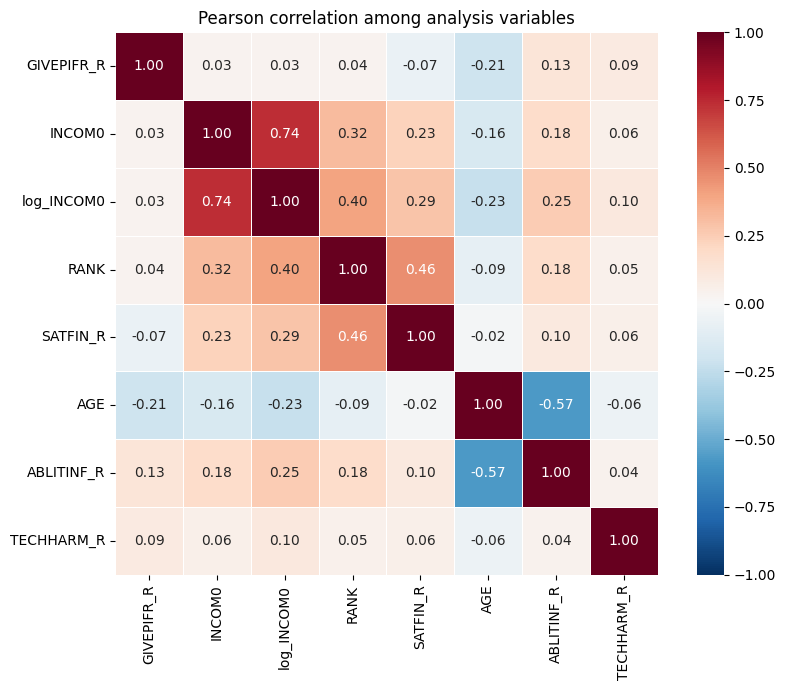

In [6]:
summary_vars = [
    "GIVEPIFR_R",
    "INCOM0", "log_INCOM0", "RANK", "SATFIN_R",
    "AGE", "ABLITINF_R", "TECHHARM_R", "FINALWT",
]

basic_numeric_summary = adt[summary_vars].describe().T
basic_numeric_summary = basic_numeric_summary[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
display(basic_numeric_summary)

# 범주형 혼동변수: 성별과 교육수준의 빈도 및 비율
sex_summary = pd.DataFrame({
    "count": adt["SEX"].value_counts().sort_index(),
    "percent": (adt["SEX"].value_counts(normalize=True).sort_index() * 100).round(2),
})
sex_summary.index.name = "SEX"
display(sex_summary)

educ_summary = pd.DataFrame({
    "count": adt["EDUC_GROUP"].value_counts().reindex(educ_categories),
    "percent": (adt["EDUC_GROUP"].value_counts(normalize=True).reindex(educ_categories) * 100).round(2),
})
educ_summary.index.name = "EDUC_GROUP"
display(educ_summary)

corr_vars = ["GIVEPIFR_R", "INCOM0", "log_INCOM0", "RANK", "SATFIN_R", "AGE", "ABLITINF_R", "TECHHARM_R"]
corr_matrix = adt[corr_vars].corr(method="pearson")
display(corr_matrix)

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
)
plt.title("Pearson correlation among analysis variables")
plt.tight_layout()
plt.show()


### 5-2. 핵심 독립변수와 개인정보 제공 동의의 관계 시각화

아래 그림은 핵심 독립변수와 종속변수(`GIVEPIFR_R`)의 관계를 기초적으로 확인하기 위한 시각화이다. `log_INCOM0`는 연속형 변수이므로 산점도와 선형 추세선을 제시하고, `RANK`와 `SATFIN_R`는 서열형 변수이므로 각 값별 평균 개인정보 제공 동의와 95% 신뢰구간을 함께 제시한다.

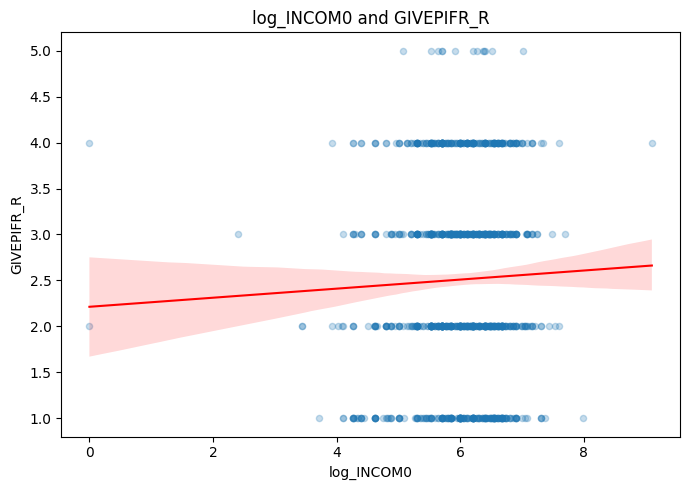

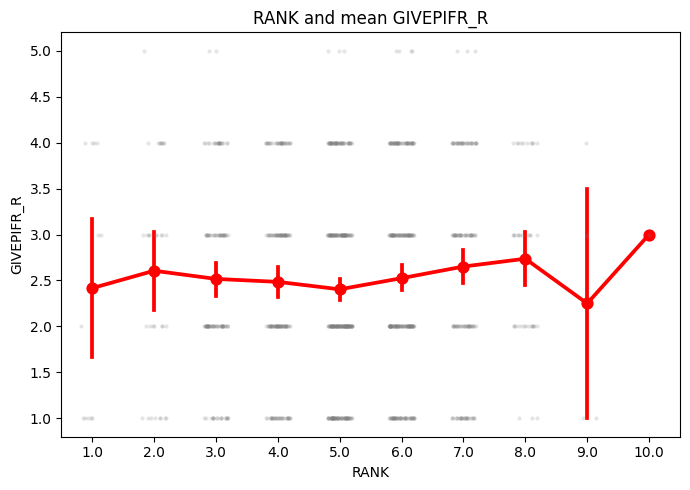

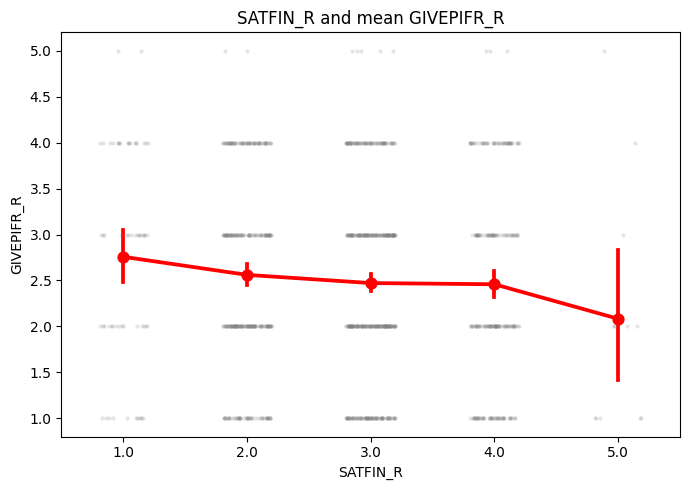

,RANK,count,mean,std
0,1.0,12,2.416667,1.378954
1,2.0,33,2.606061,1.197377
2,3.0,118,2.516949,1.010484
3,4.0,167,2.485030,1.017061
4,5.0,302,2.403974,1.054519
5,6.0,259,2.525097,1.082967
6,7.0,135,2.651852,1.135049
7,8.0,38,2.736842,0.949657
8,9.0,4,2.250000,1.500000
9,10.0,1,3.000000,NaN


,SATFIN_R,count,mean,std
0,1.0,62,2.758065,1.154968
1,2.0,319,2.561129,1.034861
2,3.0,445,2.471910,1.049344
3,4.0,231,2.458874,1.102092
4,5.0,12,2.083333,1.311372


In [10]:
# 핵심 독립변수와 개인정보 제공 동의의 관계 시각화
plt.figure(figsize=(7, 5))
sns.regplot(
    data=adt,
    x="log_INCOM0",
    y="GIVEPIFR_R",
    scatter_kws={"alpha": 0.25, "s": 20},
    line_kws={"color": "red", "linewidth": 1.5},
)
plt.title("log_INCOM0 and GIVEPIFR_R")
plt.xlabel("log_INCOM0")
plt.ylabel("GIVEPIFR_R")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.stripplot(
    data=adt,
    x="RANK",
    y="GIVEPIFR_R",
    color="gray",
    alpha=0.20,
    jitter=0.20,
    size=3,
)
sns.pointplot(
    data=adt,
    x="RANK",
    y="GIVEPIFR_R",
    errorbar=("ci", 95),
    color="red",
    markers="o",
    linestyles="-",
)
plt.title("RANK and mean GIVEPIFR_R")
plt.xlabel("RANK")
plt.ylabel("GIVEPIFR_R")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.stripplot(
    data=adt,
    x="SATFIN_R",
    y="GIVEPIFR_R",
    color="gray",
    alpha=0.20,
    jitter=0.20,
    size=3,
)
sns.pointplot(
    data=adt,
    x="SATFIN_R",
    y="GIVEPIFR_R",
    errorbar=("ci", 95),
    color="red",
    markers="o",
    linestyles="-",
)
plt.title("SATFIN_R and mean GIVEPIFR_R")
plt.xlabel("SATFIN_R")
plt.ylabel("GIVEPIFR_R")
plt.tight_layout()
plt.show()

# 기초 평균표: 핵심 서열형 독립변수 값별 개인정보 제공 동의 평균
rank_mean = adt.groupby("RANK", observed=True)["GIVEPIFR_R"].agg(["count", "mean", "std"]).reset_index()
satfin_mean = adt.groupby("SATFIN_R", observed=True)["GIVEPIFR_R"].agg(["count", "mean", "std"]).reset_index()

display(rank_mean)
display(satfin_mean)


### 5-3. 통제변수와 개인정보 제공 동의의 기초 관계

`ABLITINF_R`와 `TECHHARM_R`는 핵심 독립변수는 아니지만 개인정보 제공 동의에 영향을 줄 수 있는 대안적 설명 요인이다. 따라서 회귀분석에 앞서 두 통제변수의 값에 따라 종속변수 평균이 어떻게 달라지는지 확인한다. 아래 표는 각 통제변수 값별 `GIVEPIFR_R`의 평균을 제시하고, 그림은 평균과 95% 신뢰구간을 시각화한다.

이 단계의 목적은 두 통제변수가 독립변수처럼 이론적 가설 검증의 대상이라는 뜻이 아니라, 개인정보 제공 동의와 일정한 관련성을 가질 수 있는 변수를 회귀모형에서 보정할 필요가 있음을 경험적으로 확인하는 데 있다.


,pearson_cor_with_GIVEPIFR_R
ABLITINF_R,0.132538
TECHHARM_R,0.089175


,ABLITINF_R,count,mean,std
0,1.0,73,2.082192,1.024064
1,2.0,166,2.277108,1.036465
2,3.0,319,2.532915,1.027001
3,4.0,334,2.664671,1.025857
4,5.0,177,2.559322,1.186159


,TECHHARM_R,count,mean,std
0,1.0,83,2.493976,1.193207
1,2.0,424,2.419811,1.073288
2,3.0,356,2.485955,1.049386
3,4.0,175,2.720000,1.015059
4,5.0,31,2.806452,0.980454


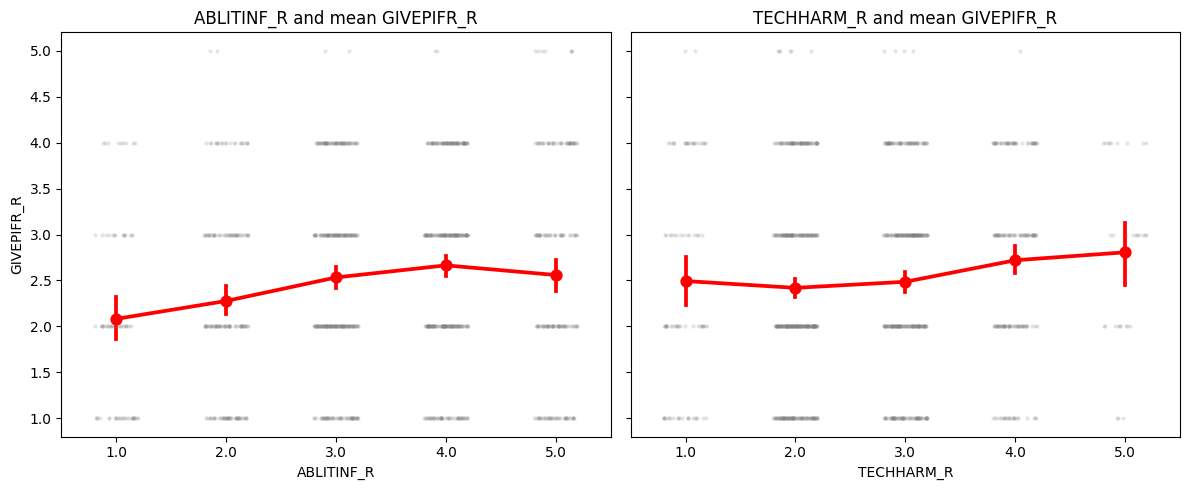

In [ ]:
# 이 부분을 좀 더 우리 수업시간에 배운 시각화 내용들을 반영해서 고쳐야 할듯함

control_corr = adt[["GIVEPIFR_R", "ABLITINF_R", "TECHHARM_R"]].corr(method="pearson").loc[
    ["ABLITINF_R", "TECHHARM_R"], ["GIVEPIFR_R"]
]
display(control_corr.rename(columns={"GIVEPIFR_R": "pearson_cor_with_GIVEPIFR_R"}))

ablitinf_mean = adt.groupby("ABLITINF_R", observed=True)["GIVEPIFR_R"].agg(["count", "mean", "std"]).reset_index()
techharm_mean = adt.groupby("TECHHARM_R", observed=True)["GIVEPIFR_R"].agg(["count", "mean", "std"]).reset_index()

display(ablitinf_mean)
display(techharm_mean)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.stripplot(
    data=adt,
    x="ABLITINF_R",
    y="GIVEPIFR_R",
    color="gray",
    alpha=0.20,
    jitter=0.20,
    size=3,
    ax=axes[0],
)
sns.pointplot(
    data=adt,
    x="ABLITINF_R",
    y="GIVEPIFR_R",
    errorbar=("ci", 95),
    color="red",
    markers="o",
    linestyles="-",
    ax=axes[0],
)
axes[0].set_title("ABLITINF_R and mean GIVEPIFR_R")
axes[0].set_xlabel("ABLITINF_R")
axes[0].set_ylabel("GIVEPIFR_R")

sns.stripplot(
    data=adt,
    x="TECHHARM_R",
    y="GIVEPIFR_R",
    color="gray",
    alpha=0.20,
    jitter=0.20,
    size=3,
    ax=axes[1],
)
sns.pointplot(
    data=adt,
    x="TECHHARM_R",
    y="GIVEPIFR_R",
    errorbar=("ci", 95),
    color="red",
    markers="o",
    linestyles="-",
    ax=axes[1],
)
axes[1].set_title("TECHHARM_R and mean GIVEPIFR_R")
axes[1].set_xlabel("TECHHARM_R")
axes[1].set_ylabel("GIVEPIFR_R")

plt.tight_layout()
plt.show()


기초 분석 결과, `ABLITINF_R`와 `GIVEPIFR_R`의 Pearson 상관계수는 약 0.133으로 약한 양의 관계를 보였다. 값별 평균을 보면 인터넷 정보판별능력이 가장 낮은 집단(`ABLITINF_R=1`)의 개인정보 제공 동의 평균은 약 2.08인 반면, `ABLITINF_R=4` 집단의 평균은 약 2.66으로 더 높게 나타났다. 이는 정보판별능력 인식이 개인정보 제공 동의와 일정한 관련성을 가질 수 있음을 보여준다.

`TECHHARM_R`와 `GIVEPIFR_R`의 Pearson 상관계수는 약 0.089로 매우 약한 양의 관계를 보였다. 기술위험 인식이 가장 높은 집단(`TECHHARM_R=5`)의 개인정보 제공 동의 평균은 약 2.81로, 일부 낮은 집단보다 높게 나타났다. 다만 이 관계는 전반적으로 강하지 않고 단조적으로 증가한다고 보기는 어렵기 때문에, 독립적인 연구가설의 대상이라기보다 개인정보 제공 동의의 차이를 보정하기 위한 통제 요인으로 해석하는 것이 적절하다.

따라서 본 연구에서는 `ABLITINF_R`와 `TECHHARM_R`를 핵심 경제 변수와 구분되는 통제변수로 포함한다. 이는 개인정보 제공 동의가 경제적 조건뿐 아니라 정보판별능력과 기술위험 인식 같은 디지털 태도에 의해서도 달라질 수 있으므로, 회귀분석에서 이러한 차이를 보정한 상태에서 경제적 요인의 관련성을 추정하기 위함이다.


## 6. 회귀분석 기본 가정 점검

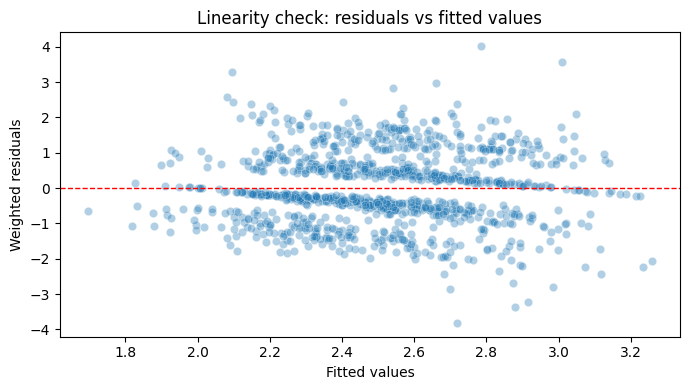

,model,durbin_watson
0,ASSUMPTION_WLS_ANALYSIS5_FULL,1.522872


,model,nobs,bp_lm_stat,bp_lm_pvalue,bp_f_stat,bp_f_pvalue,white_lm_stat,white_lm_pvalue,white_f_stat,white_f_pvalue,bp_heteroskedasticity_5pct,white_heteroskedasticity_5pct
0,ASSUMPTION_WLS_ANALYSIS5_FULL,1069,67.704136,1.227894e-10,7.153827,5.577677e-11,144.089103,2.805631e-09,2.712843,4.108896e-10,True,True


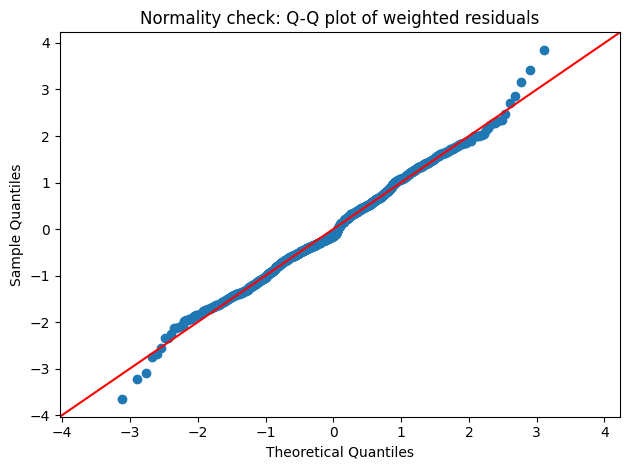

,model,jarque_bera_stat,jarque_bera_pvalue,skew,kurtosis,normality_rejected_5pct
0,ASSUMPTION_WLS_ANALYSIS5_FULL,1.279523,0.527418,0.084725,3.003575,False


,model,term,vif
0,VIF_ANALYSIS5_FULL,AGE,1.732406
1,VIF_ANALYSIS5_FULL,ABLITINF_R,1.640717
2,VIF_ANALYSIS5_FULL,C(EDUC_GROUP)[T.4년제 대학],1.566924
3,VIF_ANALYSIS5_FULL,RANK,1.446442
4,VIF_ANALYSIS5_FULL,SATFIN_R,1.314526
5,VIF_ANALYSIS5_FULL,log_INCOM0,1.309541
6,VIF_ANALYSIS5_FULL,C(EDUC_GROUP)[T.2년제 대학],1.270085
7,VIF_ANALYSIS5_FULL,C(EDUC_GROUP)[T.대학원 이상],1.176042
8,VIF_ANALYSIS5_FULL,C(SEX)[T.2.0],1.037840
9,VIF_ANALYSIS5_FULL,TECHHARM_R,1.027785


In [9]:
assumption_formula_main = (
    "GIVEPIFR_R ~ log_INCOM0 + RANK + SATFIN_R + AGE "
    "+ C(SEX) + C(EDUC_GROUP) + ABLITINF_R + TECHHARM_R"
)

# 분석 5와 같은 전체 WLS 모형으로 가정 점검
assumption_wls = smf.wls(
    formula=assumption_formula_main,
    data=adt,
    weights=adt["FINALWT"]
).fit()

# 1. 선형성: 예측값과 WLS 가중 잔차의 관계 확인
# 잔차들이 특정 패턴을 보이지 않고 무작위로 고르게 분포해 있다. -> 선형성 가정 충족
plt.figure(figsize=(7, 4))
sns.scatterplot(x=assumption_wls.fittedvalues, y=assumption_wls.wresid, alpha=0.35)
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.xlabel("Fitted values")
plt.ylabel("Weighted residuals")
plt.title("Linearity check: residuals vs fitted values")
plt.tight_layout()
plt.show()

# 2. 독립성: Durbin-Watson 통계량 확인
independence_results = pd.DataFrame([{
    "model": "ASSUMPTION_WLS_ANALYSIS5_FULL",
    "durbin_watson": durbin_watson(assumption_wls.wresid),
}])
display(independence_results)

# 3. 등분산성: Breusch-Pagan 검정과 White 검정
# wresid는 statsmodels가 WLS 계산에 사용한 가중 잔차다.
# BP/White 검정 함수는 상수항이 있는 설명변수 행렬을 요구하므로 exog는 원 설계행렬을 사용한다.
bp = het_breuschpagan(assumption_wls.wresid, assumption_wls.model.exog)
white = het_white(assumption_wls.wresid, assumption_wls.model.exog)

heteroskedasticity_results = pd.DataFrame([{
    "model": "ASSUMPTION_WLS_ANALYSIS5_FULL",
    "nobs": int(assumption_wls.nobs),
    "bp_lm_stat": bp[0],
    "bp_lm_pvalue": bp[1],
    "bp_f_stat": bp[2],
    "bp_f_pvalue": bp[3],
    "white_lm_stat": white[0],
    "white_lm_pvalue": white[1],
    "white_f_stat": white[2],
    "white_f_pvalue": white[3],
    "bp_heteroskedasticity_5pct": bp[1] < 0.05,
    "white_heteroskedasticity_5pct": white[1] < 0.05,
}])
display(heteroskedasticity_results)

# 4. 정규성: Q-Q plot과 Jarque-Bera 검정
sm.qqplot(assumption_wls.wresid, line="45", fit=True)
plt.title("Normality check: Q-Q plot of weighted residuals")
plt.tight_layout()
plt.show()

jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(assumption_wls.wresid)
normality_results = pd.DataFrame([{
    "model": "ASSUMPTION_WLS_ANALYSIS5_FULL",
    "jarque_bera_stat": jb_stat,
    "jarque_bera_pvalue": jb_pvalue,
    "skew": skew,
    "kurtosis": kurtosis,
    "normality_rejected_5pct": jb_pvalue < 0.05,
}])
display(normality_results)

# 추가 점검: 다중공선성 VIF
_, X = dmatrices(assumption_formula_main, data=adt, return_type="dataframe")
vif_rows = []
for i, col in enumerate(X.columns):
    if col == "Intercept":
        continue
    vif_rows.append({
        "model": "VIF_ANALYSIS5_FULL",
        "term": col,
        "vif": variance_inflation_factor(X.values, i),
    })

vif_results = pd.DataFrame(vif_rows).sort_values("vif", ascending=False).reset_index(drop=True)
display(vif_results)


**기본가정 점검** 

  1. 선형성

  예측값과 WLS 가중 잔차의 산점도를 확인한 결과, 잔차가 0을 중심으로 특별한 곡선 패턴 없이 퍼져 있다면 선형성 가정은 대체로 충족된다고 볼 수 있다. 

  즉, 분석 5의 전체 모형에서 log_INCOM0, RANK, SATFIN_R와 통제변수들이 GIVEPIFR_R과 완전히 비선형적인 관계를 보인다고 판단할 근거는 크지 않다. 

  정리하면:

  > 잔차-예측값 그래프에서 뚜렷한 곡선 패턴이 나타나지 않아 선형성 가정을 충족하는 것으로 판단하였다. 

  2. 독립성

  Durbin-Watson 값은 약 1.52이다. 

  Durbin-Watson은 보통 2에 가까울수록 잔차 간 자기상관이 없다고 본다. 1.52는 2보다 낮기 때문에 약한 양의 자기상관 가능성을 시사할 수 있다. 

  다만 우리 자료는 시계열 자료가 아니라 KGSS 2025년 횡단면 설문자료이다. 따라서 Durbin-Watson을 시계열 분석처럼 강하게 해석할 필요는 없다. 

  정리하면:

  > Durbin-Watson 값은 2보다 낮지만, 본 연구는 횡단면 설문자료를 사용하므로 자기상관의 직접적 증거라기보다는 참고 지표로 해석하는 것이 적절하다.

  3. *등분산성*

  Breusch-Pagan 검정과 White 검정 결과에서 p값이 매우 작게 나왔다. 

  이 경우 귀무가설인 “오차의 분산이 일정하다”를 기각한다. 즉, 이분산성이 존재한다고 볼 수 있다. 

  정리하면:
  
  > BP 검정과 White 검정 결과, 등분산성 가정은 충족되지 않는 것으로 나타났다. 따라서 회귀계수의 방향 자체보다 표준오차, p값, 신뢰구간 해석에 주의가 필요하다.  
  > wls 가중치를 적용한 후에도 여전히 이분산성이 남아있다. 
  > 이분산성 교정을 위해 가중최소자승법(WLS)을 적용한 후 가중 잔차에 대해 Breusch-Pagan 및 White 검정을 수행한 결과, $p$-값이 0.05 미만으로 나타나 통계적으로는 잔여 이분산성이 존재하는 것으로 확인되었다. 그러나 앞선 잔차 산점도에서 확인한 바와 같이 가중 잔차의 변동 폭이 전 범위에 걸쳐 시각적으로 일정하게 유지되고 있으며, WLS 적용을 통해 OLS 대비 이분산성의 왜곡 효과를 상당 부분 완화하였기에 본 모형의 추정치를 신뢰할 수 있다고 판단하였다.


  4. 정규성

  Jarque-Bera 검정의 p값은 약 0.527로 확인되었다.

  p값이 0.05보다 크므로, 잔차가 정규분포를 따른다는 귀무가설을 기각하지 않는다. 즉, 정규성 가정은 크게 위배되지 않는다고 볼 수 있다.

  Q-Q plot에서도 점들이 대체로 기준선 주변에 놓여 있다면 정규성 가정은 무난하다고 해석할 수 있다.

  정리하면:

  > Jarque-Bera 검정 결과 정규성 가정은 기각되지 않았으며, 잔차의 정규성에는 큰 문제가 없어 보인다.

정리

회귀분석의 기본 가정을 점검한 결과, 잔차-예측값 그래프에서 뚜렷한 비선형 패턴은 확인되지 않았고, Jarque-Bera 검정에서도 잔차의 정규성은 기각되지 않았다. Durbin-Watson 통계량은 약 1.52로 나타났으나, 본 연구는 횡단면 설문자료를 사용하므로 이를 자기상관의 직접적 증거로 해석하기보다는 참고 지표로 활용하였다. 한편 Breusch-Pagan 및 White 검정 결과 이분산성이 확인되어, 회귀계수의 통계적 유의성 해석에는 주의가 필요하다.


질문:  wls 를 사용해도 여전히, 등분산성 가정이 충족되지 않는다. 이 경우 어떻게 해석할 수 있을까? 

## 7. WLS 회귀분석: 분석 모형 구성

종속변수: `GIVEPIFR_R` (값이 높을수록 할인이나 무료상품을 받기 위해 개인정보를 제공하는 데 더 동의한다는 의미)

혼동변수와 통제변수는 다음과 같이 구분한다.

| 변수 | 분석상 역할 | 구분 이유 |
|---|---|---|
| `AGE` | 혼동변수 | 연령은 소득, 계층의식, 가계만족도와 관련되며 동시에 디지털 서비스 이용 경험과 개인정보 제공 태도에도 영향을 줄 수 있음 |
| `SEX` | 혼동변수 | 성별은 경제적 자원과 사회경제적 위치 인식에 영향을 줄 수 있고, 동시에 개인정보 제공 태도와 디지털 이용 양식에도 영향을 줄 수 있음 |
| `EDUC_GROUP` | 혼동변수 | 교육 수준은 소득과 계층의식을 형성하는 요인이며, 동시에 정보 이해도와 개인정보 제공 판단에도 영향을 줄 수 있음 |
| `ABLITINF_R` | 통제변수 | 연구의 핵심 관심사는 아니지만 인터넷 정보판별능력이 개인정보 제공 판단에 영향을 줄 수 있어 보정함 |
| `TECHHARM_R` | 통제변수 | 연구의 핵심 관심사는 아니지만 기술위험 인식이 개인정보 제공 판단에 영향을 줄 수 있어 보정함 |

분석별 독립변수 구성은 다음과 같다.

| 분석 | 종속변수 | 독립변수 | 혼동변수 및 통제변수 |
|---|---|---|---|
| 분석 1 | `GIVEPIFR_R` | `log_INCOM0` | `AGE`, `SEX`, `EDUC_GROUP`, `ABLITINF_R`, `TECHHARM_R` |
| 분석 2 | `GIVEPIFR_R` | `RANK` | `AGE`, `SEX`, `EDUC_GROUP`, `ABLITINF_R`, `TECHHARM_R` |
| 분석 3 | `GIVEPIFR_R` | `SATFIN_R` | `AGE`, `SEX`, `EDUC_GROUP`, `ABLITINF_R`, `TECHHARM_R` |
| 분석 4 | `GIVEPIFR_R` | `RANK`, `SATFIN_R` | `AGE`, `SEX`, `EDUC_GROUP`, `ABLITINF_R`, `TECHHARM_R` |
| 분석 5 | `GIVEPIFR_R` | `log_INCOM0`, `RANK`, `SATFIN_R` | `AGE`, `SEX`, `EDUC_GROUP`, `ABLITINF_R`, `TECHHARM_R` |


In [6]:
# 분석 1: log_INCOM0 + 통제변수
formula_analysis1 = (
    "GIVEPIFR_R ~ log_INCOM0 + AGE + C(SEX) + C(EDUC_GROUP) + ABLITINF_R + TECHHARM_R"
)
analysis1_model = smf.wls(
    formula=formula_analysis1,
    data=adt,
    weights=adt["FINALWT"]
).fit()

# 분석 2: RANK + 통제변수
formula_analysis2 = (
    "GIVEPIFR_R ~ RANK + AGE + C(SEX) + C(EDUC_GROUP) + ABLITINF_R + TECHHARM_R"
)
analysis2_model = smf.wls(
    formula=formula_analysis2,
    data=adt,
    weights=adt["FINALWT"]
).fit()

# 분석 3: SATFIN_R + 통제변수
formula_analysis3 = (
    "GIVEPIFR_R ~ SATFIN_R + AGE + C(SEX) + C(EDUC_GROUP) + ABLITINF_R + TECHHARM_R"
)
analysis3_model = smf.wls(
    formula=formula_analysis3,
    data=adt,
    weights=adt["FINALWT"]
).fit()

# 분석 4: RANK, SATFIN_R + 통제변수
formula_analysis4 = (
    "GIVEPIFR_R ~ RANK + SATFIN_R + AGE "
    "+ C(SEX) + C(EDUC_GROUP) + ABLITINF_R + TECHHARM_R"
)
analysis4_model = smf.wls(
    formula=formula_analysis4,
    data=adt,
    weights=adt["FINALWT"]
).fit()

# 분석 5: log_INCOM0, RANK, SATFIN_R + 통제변수
formula_analysis5 = (
    "GIVEPIFR_R ~ log_INCOM0 + RANK + SATFIN_R + AGE "
    "+ C(SEX) + C(EDUC_GROUP) + ABLITINF_R + TECHHARM_R"
)
analysis5_model = smf.wls(
    formula=formula_analysis5,
    data=adt,
    weights=adt["FINALWT"]
).fit()

models = {
    "ANALYSIS_1_WLS_GIVEPIFR_R_logINCOM0": analysis1_model,
    "ANALYSIS_2_WLS_GIVEPIFR_R_RANK": analysis2_model,
    "ANALYSIS_3_WLS_GIVEPIFR_R_SATFIN_R": analysis3_model,
    "ANALYSIS_4_WLS_GIVEPIFR_R_SUBJECTIVE": analysis4_model,
    "ANALYSIS_5_WLS_GIVEPIFR_R_FULL": analysis5_model,
}

# 핵심 독립변수 중심 요약표
key_terms_by_model = {
    "ANALYSIS_1_WLS_GIVEPIFR_R_logINCOM0": ["log_INCOM0"],
    "ANALYSIS_2_WLS_GIVEPIFR_R_RANK": ["RANK"],
    "ANALYSIS_3_WLS_GIVEPIFR_R_SATFIN_R": ["SATFIN_R"],
    "ANALYSIS_4_WLS_GIVEPIFR_R_SUBJECTIVE": ["RANK", "SATFIN_R"],
    "ANALYSIS_5_WLS_GIVEPIFR_R_FULL": ["log_INCOM0", "RANK", "SATFIN_R"],
}

result_rows = []
for model_name, model in models.items():
    conf_int = model.conf_int()
    for term in key_terms_by_model[model_name]:
        result_rows.append({
            "model": model_name,
            "term": term,
            "coef": model.params[term],
            "std_err": model.bse[term],
            "p_value": model.pvalues[term],
            "ci_low": conf_int.loc[term, 0],
            "ci_high": conf_int.loc[term, 1],
            "nobs": int(model.nobs),
            "r_squared": model.rsquared,
            "adj_r_squared": model.rsquared_adj,
        })

wls_key_results = pd.DataFrame(result_rows)
display(wls_key_results)

# 전체 회귀표
for model_name, model in models.items():
    print("=" * 100)
    print(model_name)
    print(model.summary())


,model,term,coef,std_err,p_value,ci_low,ci_high,nobs,r_squared,adj_r_squared
0,ANALYSIS_1_WLS_GIVEPIFR_R_logINCOM0,log_INCOM0,-0.033158,0.050727,0.513475,-0.132694,0.066378,1069,0.054404,0.047267
1,ANALYSIS_2_WLS_GIVEPIFR_R_RANK,RANK,0.021285,0.023551,0.366316,-0.024927,0.067497,1069,0.054751,0.047617
2,ANALYSIS_3_WLS_GIVEPIFR_R_SATFIN_R,SATFIN_R,-0.078716,0.038476,0.041019,-0.154215,-0.003218,1069,0.057743,0.050632
3,ANALYSIS_4_WLS_GIVEPIFR_R_SUBJECTIVE,RANK,0.051914,0.026059,0.046612,0.000780,0.103047,1069,0.061261,0.053283
4,ANALYSIS_4_WLS_GIVEPIFR_R_SUBJECTIVE,SATFIN_R,-0.115560,0.042642,0.006837,-0.199232,-0.031887,1069,0.061261,0.053283
5,ANALYSIS_5_WLS_GIVEPIFR_R_FULL,log_INCOM0,-0.039359,0.054083,0.466921,-0.145480,0.066762,1069,0.061731,0.052863
6,ANALYSIS_5_WLS_GIVEPIFR_R_FULL,RANK,0.057186,0.027053,0.034762,0.004102,0.110270,1069,0.061731,0.052863
7,ANALYSIS_5_WLS_GIVEPIFR_R_FULL,SATFIN_R,-0.112107,0.042914,0.009120,-0.196315,-0.027900,1069,0.061731,0.052863


ANALYSIS_1_WLS_GIVEPIFR_R_logINCOM0
                            WLS Regression Results                            
Dep. Variable:             GIVEPIFR_R   R-squared:                       0.054
Model:                            WLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     7.623
Date:                Mon, 01 Jun 2026   Prob (F-statistic):           5.94e-10
Time:                        21:17:06   Log-Likelihood:                -1639.4
No. Observations:                1069   AIC:                             3297.
Df Residuals:                    1060   BIC:                             3342.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

## 8. 분석결과

*아래 해석은 모든 분석에서 혼동변수(`AGE`, `SEX`, `EDUC_GROUP`)와 통제변수(`ABLITINF_R`, `TECHHARM_R`)를 보정한 WLS 결과를 기준으로 한다.*


> **분석 1:** `log_INCOM0`의 계수는 -0.033이고 p값은 0.513으로 통계적으로 유의하지 않다. 즉, 객관적 경제 조건인 월평균 가구소득은 개인정보 제공 동의와 뚜렷한 관련을 보이지 않는다.

> **분석 2:** `RANK`의 계수는 0.021이고 p값은 0.366으로 통계적으로 유의하지 않다. 주관적 계층의식을 단독으로 투입했을 때는 개인정보 제공 동의와 유의한 관련이 확인되지 않는다.

> **분석 3:** `SATFIN_R`의 계수는 -0.079이고 p값은 0.041로 5% 수준에서 유의하다. `SATFIN_R`은 값이 높을수록 가계상태 만족도가 높다는 뜻이므로, 가계상태 만족도가 높을수록 개인정보 제공 동의는 낮아지는 방향이다. 반대로 가계상태 만족도가 낮을수록 개인정보 제공 동의가 높다고 해석할 수 있다.

> **분석 4:** 주관적 경제상태 평가 변수인 `RANK`, `SATFIN_R`를 함께 투입한 결과, `RANK`는 양의 방향으로 유의하고(coef=0.052, p=0.047), `SATFIN_R`은 음의 방향으로 유의하다(coef=-0.116, p=0.007). 즉, 주관적 계층의식이 높을수록 개인정보 제공 동의가 높고, 가계상태 만족도가 낮을수록 개인정보 제공 동의가 높은 경향이 나타난다.

> **분석 5:** 객관적 경제 조건(`log_INCOM0`)과 주관적 경제상태 평가(`RANK`, `SATFIN_R`)를 함께 투입한 결과, `log_INCOM0`는 유의하지 않다(p=0.467). 반면 `RANK`는 양의 방향으로 유의하고(coef=0.057, p=0.035), `SATFIN_R`은 음의 방향으로 유의하다(coef=-0.112, p=0.009). 따라서 객관적 소득보다는 주관적 계층의식과 현재 가계상태 만족도가 개인정보 제공 동의와 더 관련되어 있는 것으로 보인다.

>> 전체적으로 설명력은 R-squared 기준 약 0.054~0.062이다.   
>> 분석 4와 분석 5에서 `RANK`와 `SATFIN_R`의 방향과 유의성이 비교적 일관되게 나타난다.


## 9. 참고사항

- 모든 WLS 분석의 종속변수는 `GIVEPIFR_R`이다. 값이 높을수록 할인/무료상품을 위한 개인정보 제공 동의가 높다는 의미이다.
- WLS 회귀에서 계수가 양수이면 해당 독립변수 또는 혼동변수/통제변수가 증가할수록 개인정보 제공 동의 수준이 높아지는 방향이며, 계수가 음수이면 해당 변수가 증가할수록 개인정보 제공 동의 수준이 낮아지는 방향이다.
- 분석 1은 **객관적 경제 조건**인 `log_INCOM0`의 관계를 확인한다.
- 분석 2는 주관적 계층의식 `RANK`의 관계를 확인한다.
- 분석 3은 가계상태 만족도 `SATFIN_R`의 관계를 확인한다.
- 분석 4는 **주관적 경제상태 평가**인 `RANK`, `SATFIN_R`를 동시에 투입하여 '경제적 위치와 현재 가계상태에 대한 개인의 평가'를 살펴본다. 
- 분석 5는 `log_INCOM0`, `RANK`, `SATFIN_R`를 동시에 투입해 객관적 소득까지 포함한 종합 관계를 확인한다.
- `AGE`, `SEX`, `EDUC_GROUP`은 핵심 독립변수와 종속변수 모두에 영향을 줄 수 있는 혼동변수로 설정하였다.
- `ABLITINF_R`, `TECHHARM_R`는 개인정보 제공 판단에 영향을 줄 수 있지만 연구의 핵심 관심 변수는 아니므로 통제변수로 설정하였다.
- `SATFIN_R`, `ABLITINF_R`는 모두 값이 높을수록 각각 가계상태 만족, 정보판별능력이 높다는 뜻이다.
- `TECHHARM_R`는 값이 높을수록 기술위험 인식이 높다는 뜻이다.  
- `EDUC_GROUP`은 원 학력 변수 `EDUC`를 고졸 이하, 2년제 대학, 4년제 대학, 대학원 이상으로 재범주화한 변수이며 회귀식에서는 범주형으로 처리한다.


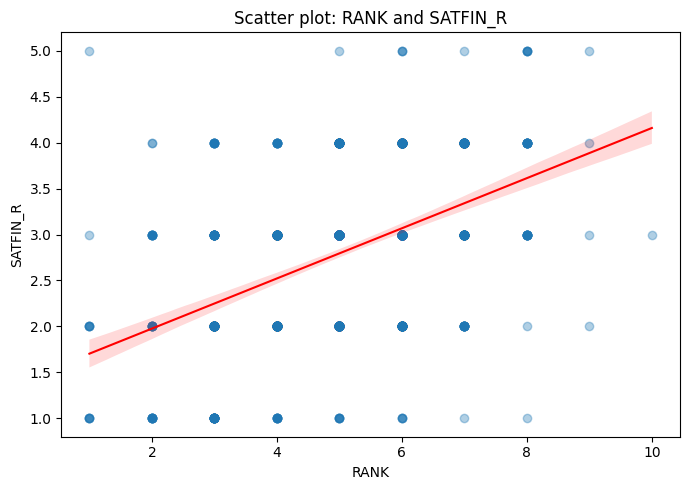

,variable_x,variable_y,pearson_cor,n
0,RANK,SATFIN_R,0.463484,1069


In [11]:
# RANK와 SATFIN_R의 산점도 및 상관관계 확인
rank_satfin = adt[["RANK", "SATFIN_R"]].dropna()

plt.figure(figsize=(7, 5))
sns.regplot(
    data=rank_satfin,
    x="RANK",
    y="SATFIN_R",
    scatter_kws={"alpha": 0.35},
    line_kws={"color": "red", "linewidth": 1.5},
)
plt.xlabel("RANK")
plt.ylabel("SATFIN_R")
plt.title("Scatter plot: RANK and SATFIN_R")
plt.tight_layout()
plt.show()

# Pearson 상관계수(cor)
cor_rank_satfin = rank_satfin["RANK"].corr(rank_satfin["SATFIN_R"], method="pearson")
display(pd.DataFrame({
    "variable_x": ["RANK"],
    "variable_y": ["SATFIN_R"],
    "pearson_cor": [cor_rank_satfin],
    "n": [len(rank_satfin)],
}))


## 10. 자료와 방법

본 연구는 경제적 조건과 경제상태에 대한 주관적 평가가 개인정보 제공 동의에 영향을 미치는가를 경험적으로 검토한다. 구체적으로 객관적 경제 조건인 '월평균 가구소득'과 주관적 경제상태에 대한 평가인 '주관적 계층의식' 및 '가계상태 만족도'이 혜택(할인, 무료상품 제공)을 받기 위한 개인정보 제공 동의와 어떠한 관련을 갖는지를 분석한다. 이를 위해 2025년 한국종합사회조사(Korean General Social Survey, KGSS) 자료를 사용하였다. KGSS는 한국 사회 구성원의 인식, 태도, 사회경제적 특성을 조사하는 개인 수준의 설문자료이며, 본 연구는 이 중 개인정보 제공 태도, 소득, 주관적 계층의식, 가계상태 만족도, 인구사회학적 특성, 디지털 태도 관련 문항을 활용하였다.

분석 대상 표본은 연구에 사용된 변수에 결측이 없는 응답자로 한정하였다. 원자료는 1,211명으로 구성되어 있으며, 종속변수, 핵심 독립변수, 혼동변수, 통제변수, 표본가중치에 결측이 있는 사례를 제외한 최종 분석 표본은 1,069명이다. 결측 처리 과정에서는 KGSS 자료의 공통 결측 코드인 `-8`을 결측값으로 처리하였고, `ABLITINF` 문항의 `-1`은 비해당 응답으로 보아 결측값으로 처리하였다.

종속변수는 할인이나 무료상품을 받기 위해 개인정보를 제공하는 데 동의하는 정도를 나타내는 `GIVEPIFR_R`이다. 원문항 `GIVEPIFR`은 1=매우 동의, 5=매우 반대의 방향으로 측정되어 있으므로, 본 연구에서는 해석의 일관성을 위해 이를 역코딩하였다. 따라서 분석에 사용된 `GIVEPIFR_R`은 값이 높을수록 할인이나 무료상품을 위한 개인정보 제공 동의가 높다는 의미를 갖는다.

핵심 독립변수는 객관적 경제 조건과 주관적 경제상태 평가로 구분하였다. 객관적 경제 조건은 월평균 가구소득 `INCOM0`에 로그 변환을 적용한 `log_INCOM0 = log(INCOM0 + 1)`로 측정하였다. 주관적 경제상태 평가는 두 변수로 측정하였다. 첫째, `RANK`는 응답자가 자신을 어느 계층에 속한다고 인식하는지를 나타내는 주관적 계층의식 변수이며, 값이 높을수록 자신을 더 높은 계층에 속한다고 평가한다. 둘째, `SATFIN_R`은 현재 가계상태에 대한 만족도를 나타내는 변수이다. 원문항 `SATFIN`을 역코딩하여 값이 높을수록 현재 가계상태에 더 만족한다는 의미가 되도록 구성하였다.

본 연구는 개인 수준 자료를 분석하므로, 성별과 교육수준을 포함한 인구사회학적 배경 요인을 혼동변수로 설정하였다. 구체적으로 `AGE`, `SEX`, `EDUC_GROUP`을 혼동변수로 포함하였다. 연령은 생애주기에 따라 소득, 계층의식, 가계만족도에 영향을 줄 수 있으며, 동시에 디지털 서비스 이용 경험과 개인정보 제공 태도에도 영향을 줄 수 있다. 성별은 노동시장 지위와 경제적 자원, 사회경제적 위치 인식에 영향을 줄 수 있고, 동시에 개인정보 제공 및 프라이버시 태도에도 차이를 만들 수 있다. 교육수준은 소득과 계층의식 형성에 영향을 주는 대표적인 사회경제적 배경 요인이며, 동시에 정보 이해도와 개인정보 제공 판단에도 영향을 줄 수 있다. 이에 따라 교육수준은 원변수 `EDUC`를 고졸 이하, 2년제 대학, 4년제 대학, 대학원 이상의 네 범주로 재분류한 `EDUC_GROUP`으로 사용하였다.

이와 별도로 `ABLITINF_R`와 `TECHHARM_R`는 통제변수로 포함하였다. `ABLITINF_R`는 인터넷 정보판별능력을 나타내며, 값이 높을수록 정보판별능력이 높다는 의미가 되도록 역코딩하였다. `TECHHARM_R`는 기술위험 인식을 나타내며, 값이 높을수록 기술이 초래할 수 있는 위험을 더 크게 인식한다는 의미가 되도록 역코딩하였다. 두 변수는 본 연구의 핵심 관심사인 경제적 조건은 아니지만, 개인정보 제공 동의에 영향을 줄 수 있는 디지털 역량 및 기술위험 태도이므로 회귀모형에 포함하여 보정하였다.

분석은 세 단계로 진행하였다. 첫째, 분석에 사용된 모든 변수의 기초 요약값을 제시하였다. 연속형 및 서열형 변수에 대해서는 평균, 표준편차, 최솟값, 사분위수, 최댓값을 확인하였고, 범주형 변수인 성별과 교육수준에 대해서는 빈도와 비율을 산출하였다. 둘째, 주요 변수 간 상관관계와 시각화를 통해 독립변수와 종속변수의 기초적 관계를 확인하였다. `log_INCOM0`와 `GIVEPIFR_R`의 관계는 산점도와 선형 추세선으로 제시하였고, `RANK`, `SATFIN_R`, `ABLITINF_R`, `TECHHARM_R`와 `GIVEPIFR_R`의 관계는 각 값별 평균과 95% 신뢰구간을 통해 시각화하였다. 또한 `RANK`와 `SATFIN_R` 사이의 관계를 산점도와 Pearson 상관계수로 확인하였다. 셋째, 혼동변수와 통제변수를 보정한 상태에서 가중최소자승법(Weighted Least Squares, WLS) 회귀분석을 실시하였다.

회귀분석에서 KGSS의 최종 표본가중치인 `FINALWT`를 적용하였다. 표본조사 자료는 모집단의 성별, 연령, 지역 등 분포를 완전히 반영하지 못할 수 있으므로, `FINALWT`를 사용하여 표본의 모집단 대표성을 보정하였다. 모든 회귀모형의 종속변수는 `GIVEPIFR_R`이며, 혼동변수인 `AGE`, `SEX`, `EDUC_GROUP`과 통제변수인 `ABLITINF_R`, `TECHHARM_R`를 공통적으로 포함하였다. 분석 1은 객관적 경제 조건인 `log_INCOM0`만을 핵심 독립변수로 투입하였고, 분석 2는 주관적 계층의식 `RANK`, 분석 3은 가계상태 만족도 `SATFIN_R`를 각각 투입하였다. 분석 4는 주관적 경제상태 평가 변수인 `RANK`와 `SATFIN_R`를 동시에 투입하였고, 분석 5는 객관적 경제 조건과 주관적 경제상태 평가를 함께 고려하기 위해 `log_INCOM0`, `RANK`, `SATFIN_R`를 모두 투입하였다.

분석 모형은 다음과 같이 요약할 수 있다. 분석 1은 월평균 가구소득이 개인정보 제공 동의와 관련되는지를 확인하는 모형이고, 분석 2와 분석 3은 각각 주관적 계층의식과 가계상태 만족도의 개별 관련성을 확인하는 모형이다. 분석 4는 두 주관적 경제상태 평가 변수를 동시에 고려했을 때 각각의 독립적 관련성이 유지되는지를 검토하는 모형이며, 분석 5는 객관적 소득을 함께 보정한 뒤에도 주관적 계층의식과 가계상태 만족도가 개인정보 제공 동의와 관련되는지를 확인하는 최종 모형이다. 이를 통해 본 연구는 개인정보 제공 동의가 객관적 소득 수준 자체보다 개인이 자신의 경제적 위치와 현재 가계상태를 어떻게 평가하는가와 더 밀접하게 관련되는지를 경험적으로 검토한다.


## 11. 통계모형: 가중최소자승법(WLS)

본 연구의 종속변수인 `GIVEPIFR_R`은 할인이나 무료상품을 받기 위한 개인정보 제공 동의 수준을 나타내는 1점에서 5점 범위의 태도 변수이다. 본 연구는 경제적 조건과 경제상태 평가가 개인정보 제공 동의와 갖는 선형적 관련성을 추정하기 위해 회귀분석을 사용하였다. 다만 본 연구자료는 표본조사 자료이므로, 표본에 포함된 응답자가 모집단에서 동일한 대표성을 갖는다고 가정하기 어렵다. 이에 따라 KGSS에서 제공하는 최종 표본가중치 `FINALWT`를 적용한 가중최소자승법(Weighted Least Squares, WLS)을 사용하였다.

WLS는 일반 최소자승법(Ordinary Least Squares, OLS)과 마찬가지로 종속변수와 설명변수 사이의 평균적 선형 관계를 추정하지만, 각 관측치에 동일한 비중을 부여하지 않고 가중치를 반영한다는 점에서 차이가 있다. OLS가 모든 응답자를 동일한 관측치로 취급하는 반면, WLS는 가중치가 큰 응답자의 정보가 추정에 더 크게 반영되도록 한다. 본 연구에서 사용한 `FINALWT`는 KGSS 표본이 모집단의 성별, 연령, 지역 등 분포를 더 잘 반영하도록 조정하기 위한 표본가중치이다. 따라서 WLS 추정은 단순 표본 내 관계가 아니라, 표본가중치를 반영한 모집단 수준의 관계에 더 가깝게 해석할 수 있다.

본 연구의 기본 회귀모형은 다음과 같이 표현할 수 있다.

\[
GIVEPIFR\_R_i = \beta_0 + \beta_1 Economic_i + \beta_2 AGE_i + \beta_3 SEX_i + \beta_4 EDUC\_GROUP_i + \beta_5 ABLITINF\_R_i + \beta_6 TECHHARM\_R_i + \epsilon_i
\]

여기서 `GIVEPIFR_R`은 응답자 \(i\)의 개인정보 제공 동의 수준이며, `Economic`은 분석 모형에 따라 `log_INCOM0`, `RANK`, `SATFIN_R` 또는 이들의 조합을 의미한다. `AGE`, `SEX`, `EDUC_GROUP`은 혼동변수로 포함하였고, `ABLITINF_R`, `TECHHARM_R`는 통제변수로 포함하였다. 범주형 변수인 성별과 교육수준은 회귀식에서 범주형 변수로 처리하였다. 각 모형은 동일한 혼동변수와 통제변수를 포함한 상태에서 핵심 독립변수의 계수와 통계적 유의성을 비교하도록 설계하였다.

WLS 추정은 다음의 가중 잔차제곱합을 최소화하는 방식으로 이루어진다.

\[
\sum_{i=1}^{n} w_i (Y_i - X_i\beta)^2
\]

여기서 \(w_i\)는 응답자 \(i\)에게 부여된 표본가중치이며, 본 연구에서는 `FINALWT`를 사용하였다. 이 식은 가중치가 큰 응답자의 잔차가 추정 과정에서 더 크게 반영됨을 의미한다. 따라서 WLS는 표본 설계와 대표성 보정이 필요한 설문자료 분석에서 유용한 방법이다.

회귀계수는 다른 변수를 일정하게 통제한 상태에서 해당 독립변수가 한 단위 증가할 때 개인정보 제공 동의(`GIVEPIFR_R`)가 평균적으로 얼마나 변화하는지를 의미한다. 계수가 양수이면 해당 변수가 증가할수록 개인정보 제공 동의가 높아지는 방향으로 해석하고, 계수가 음수이면 해당 변수가 증가할수록 개인정보 제공 동의가 낮아지는 방향으로 해석한다. 예를 들어 `RANK`의 계수가 양수이면 주관적 계층의식이 높을수록 개인정보 제공 동의가 높다는 의미이며, `SATFIN_R`의 계수가 음수이면 가계상태 만족도가 높을수록 개인정보 제공 동의가 낮다는 의미이다.

본 연구는 총 네 개의 WLS 모형을 추정하였다. 분석 1은 객관적 경제 조건인 `log_INCOM0`의 효과를 확인하는 모형이고, 분석 2는 주관적 계층의식 `RANK`, 분석 3은 가계상태 만족도 `SATFIN_R`의 개별 관련성을 확인하는 모형이다. 분석 4는 `log_INCOM0`, `RANK`, `SATFIN_R`를 모두 포함하여 객관적 경제 조건과 주관적 경제상태 평가의 상대적 관련성을 비교하는 최종 모형이다.

WLS 모형의 적절성을 검토하기 위해 잔차-예측값 산점도를 통해 선형성을 확인하고, Durbin-Watson 통계량, Breusch-Pagan 검정, White 검정, Jarque-Bera 검정, VIF를 함께 확인하였다. 본 연구자료는 횡단면 설문자료이므로 Durbin-Watson 통계량은 시계열 자기상관 검정처럼 강하게 해석하지 않고 참고 지표로 사용하였다. 또한 Breusch-Pagan 및 White 검정에서 잔여 이분산성이 확인되었으므로, 회귀계수의 방향과 통계적 유의성 해석에는 주의가 필요하다. 다만 WLS는 표본가중치를 반영하여 모집단 대표성을 보정하는 데 목적이 있으며, 본 연구에서는 동일한 가중치와 동일한 혼동·통제변수를 적용한 여러 모형을 비교함으로써 핵심 경제 변수들의 상대적 관련성을 평가하였다.


< 안 쓴 부분>


본 연구의 기본 회귀모형은 다음과 같이 표현할 수 있다.

\[
GIVEPIFR\_R_i = \beta_0 + \beta_1 Economic_i + \beta_2 AGE_i + \beta_3 SEX_i + \beta_4 EDUC\_GROUP_i + \beta_5 ABLITINF\_R_i + \beta_6 TECHHARM\_R_i + \epsilon_i
\]

여기서 `GIVEPIFR_R`은 응답자 \(i\)의 개인정보 제공 동의 수준이며, `Economic`은 분석 모형에 따라 `log_INCOM0`, `RANK`, `SATFIN_R` 또는 이들의 조합을 의미한다. `AGE`, `SEX`, `EDUC_GROUP`은 혼동변수로 포함하였고, `ABLITINF_R`, `TECHHARM_R`는 통제변수로 포함하였다. 범주형 변수인 성별과 교육수준은 회귀식에서 범주형 변수로 처리하였다. 각 모형은 동일한 혼동변수와 통제변수를 포함한 상태에서 핵심 독립변수의 계수와 통계적 유의성을 비교하도록 설계하였다.

WLS 추정은 다음의 가중 잔차제곱합을 최소화하는 방식으로 이루어진다.

\[
\sum_{i=1}^{n} w_i (Y_i - X_i\beta)^2
\]

여기서 \(w_i\)는 응답자 \(i\)에게 부여된 표본가중치이며, 본 연구에서는 `FINALWT`를 사용하였다. 이 식은 가중치가 큰 응답자의 잔차가 추정 과정에서 더 크게 반영됨을 의미한다. 따라서 WLS는 표본 설계와 대표성 보정이 필요한 설문자료 분석에서 유용한 방법이다.


## 12. 조절효과 검증: `ABLITINF_R`와 `TECHHARM_R`

앞선 분석에서는 `ABLITINF_R`와 `TECHHARM_R`를 통제변수로 포함하였다. 그러나 두 변수는 경제적 조건과 개인정보 제공 동의의 관계를 조절하는 변수로 작동할 가능성도 있다. 조절효과란 독립변수와 종속변수의 관계가 제3의 변수 수준에 따라 달라지는 경우를 의미한다. 예를 들어 기술위험 인식이 높은 응답자는 경제적 보상이 있더라도 개인정보 제공의 위험을 더 크게 평가할 수 있으므로, `SATFIN_R` 또는 `RANK`와 개인정보 제공 동의 사이의 관계가 `TECHHARM_R` 수준에 따라 달라질 수 있다. 마찬가지로 인터넷 정보판별능력이 높은 응답자는 개인정보 제공의 위험과 편익을 다르게 판단할 수 있으므로, 경제상태 평가와 개인정보 제공 동의의 관계가 `ABLITINF_R` 수준에 따라 달라질 수 있다.

이를 확인하기 위해 본 절에서는 상호작용항을 포함한 WLS 모형을 추가로 추정한다. 핵심 독립변수는 기존 최종 모형과 동일하게 `log_INCOM0`, `RANK`, `SATFIN_R`로 두고, 조절효과 검증 대상은 `RANK`와 `SATFIN_R`의 효과가 `ABLITINF_R` 또는 `TECHHARM_R`에 따라 달라지는지로 한정한다. 상호작용항의 다중공선성을 완화하고 계수 해석을 쉽게 하기 위해 `RANK`, `SATFIN_R`, `ABLITINF_R`, `TECHHARM_R`는 평균중심화한 변수를 사용한다.

판단 기준은 다음과 같다. 상호작용항(`RANK_c:ABLITINF_R_c`, `SATFIN_R_c:ABLITINF_R_c`, `RANK_c:TECHHARM_R_c`, `SATFIN_R_c:TECHHARM_R_c`)의 p값이 통계적으로 유의하면 해당 변수는 조절변수로 작동할 가능성이 있다고 해석한다. 반대로 상호작용항이 유의하지 않으면, 본 자료에서는 조절효과가 확인되지 않았다고 해석한다.

In [ ]:
# 조절효과 검증을 위한 평균중심화
moderation_data = adt.copy()
for col in ["RANK", "SATFIN_R", "ABLITINF_R", "TECHHARM_R"]:
    moderation_data[f"{col}_c"] = moderation_data[col] - moderation_data[col].mean()

# 모형 1: ABLITINF_R가 RANK 및 SATFIN_R의 효과를 조절하는지 검증
formula_moderation_ablitinf = (
    "GIVEPIFR_R ~ log_INCOM0 + RANK_c * ABLITINF_R_c + SATFIN_R_c * ABLITINF_R_c + AGE "
    "+ C(SEX) + C(EDUC_GROUP) + TECHHARM_R"
)
moderation_ablitinf_model = smf.wls(
    formula=formula_moderation_ablitinf,
    data=moderation_data,
    weights=moderation_data["FINALWT"],
).fit()

# 모형 2: TECHHARM_R가 RANK 및 SATFIN_R의 효과를 조절하는지 검증
formula_moderation_techharm = (
    "GIVEPIFR_R ~ log_INCOM0 + RANK_c * TECHHARM_R_c + SATFIN_R_c * TECHHARM_R_c + AGE "
    "+ C(SEX) + C(EDUC_GROUP) + ABLITINF_R"
)
moderation_techharm_model = smf.wls(
    formula=formula_moderation_techharm,
    data=moderation_data,
    weights=moderation_data["FINALWT"],
).fit()

# 모형 3: 두 조절변수의 상호작용항을 동시에 포함한 통합 검증
formula_moderation_full = (
    "GIVEPIFR_R ~ log_INCOM0 + RANK_c + SATFIN_R_c + ABLITINF_R_c + TECHHARM_R_c "
    "+ RANK_c:ABLITINF_R_c + SATFIN_R_c:ABLITINF_R_c "
    "+ RANK_c:TECHHARM_R_c + SATFIN_R_c:TECHHARM_R_c "
    "+ AGE + C(SEX) + C(EDUC_GROUP)"
)
moderation_full_model = smf.wls(
    formula=formula_moderation_full,
    data=moderation_data,
    weights=moderation_data["FINALWT"],
).fit()

moderation_models = {
    "MODERATION_ABLITINF_R": moderation_ablitinf_model,
    "MODERATION_TECHHARM_R": moderation_techharm_model,
    "MODERATION_FULL": moderation_full_model,
}

interaction_terms_by_model = {
    "MODERATION_ABLITINF_R": ["RANK_c:ABLITINF_R_c", "SATFIN_R_c:ABLITINF_R_c"],
    "MODERATION_TECHHARM_R": ["RANK_c:TECHHARM_R_c", "SATFIN_R_c:TECHHARM_R_c"],
    "MODERATION_FULL": [
        "RANK_c:ABLITINF_R_c",
        "SATFIN_R_c:ABLITINF_R_c",
        "RANK_c:TECHHARM_R_c",
        "SATFIN_R_c:TECHHARM_R_c",
    ],
}

moderation_rows = []
for model_name, model in moderation_models.items():
    conf_int = model.conf_int()
    for term in interaction_terms_by_model[model_name]:
        moderation_rows.append({
            "model": model_name,
            "interaction_term": term,
            "coef": model.params[term],
            "std_err": model.bse[term],
            "p_value": model.pvalues[term],
            "ci_low": conf_int.loc[term, 0],
            "ci_high": conf_int.loc[term, 1],
            "nobs": int(model.nobs),
            "r_squared": model.rsquared,
            "adj_r_squared": model.rsquared_adj,
            "moderation_5pct": model.pvalues[term] < 0.05,
            "moderation_10pct": model.pvalues[term] < 0.10,
        })

moderation_results = pd.DataFrame(moderation_rows)
display(moderation_results)

# 전체 회귀표 확인
for model_name, model in moderation_models.items():
    print("=" * 100)
    print(model_name)
    print(model.summary())


### 조절효과 해석 방법

위 표에서 핵심은 상호작용항의 p값이다. 예를 들어 `SATFIN_R_c:TECHHARM_R_c`가 유의하면, 가계상태 만족도(`SATFIN_R`)와 개인정보 제공 동의(`GIVEPIFR_R`)의 관계가 기술위험 인식(`TECHHARM_R`) 수준에 따라 달라진다고 해석할 수 있다. 반대로 상호작용항이 유의하지 않으면, 해당 변수는 본 자료에서 조절변수로 작동한다고 보기 어렵다.

따라서 `ABLITINF_R`와 `TECHHARM_R`를 조절변수로 주장하려면, 단순히 이 변수들이 개인정보 제공 동의와 관련된다는 것만으로는 부족하다. `RANK` 또는 `SATFIN_R`와의 상호작용항이 통계적으로 유의해야 한다. 만약 상호작용항이 유의하지 않다면 본 연구에서는 두 변수를 조절변수가 아니라, 기존 분석처럼 개인정보 제공 동의에 영향을 줄 수 있는 디지털 역량 및 기술위험 태도 관련 통제변수로 처리하는 것이 더 적절하다.

 2순위: USESHOPP
  USESHOPP: 인터넷활용목적별사용빈도6: 온라인쇼핑, 고지서납부, 기타금융거래

  이것도 매우 적절합니다. 종속변수가 “할인이나 무료상품을 받기 위해 개인정보를 제공할 것인가”이기 때문에, 온라인 쇼핑이나 금융거래 경험은 개인정보 제공 상황을 실제로 경험하는 정도와 관련됩니다.

  논리:

  > 온라인 쇼핑과 금융거래를 자주 하는 사람은 개인정보 제공을 일상적인 거래의 일부로 경험할 가능성이 높다. 따라서 경제적 보상에 대한 민감성이 개인정보 제공 동의로 이어지는 정도는 온라인 거래 경험에 따라 달라질 수 있다.

  조절가설 예시:

  > 온라인 쇼핑 및 금융거래 이용 빈도(USESHOPP)는 경제상태 평가와 개인정보 제공 동의의 관계를 조절할 것이다. 온라인 거래 빈도가 높을수록 경제적 보상과 개인정보 제공 사이의 교환을 더 익숙하게 받아들여, SATFIN_R 또는 RANK의 효과가 더 강하게 나타날 수 있
  > 다.

  상호작용항:

  SATFIN_R_c:USESHOPP_c
  RANK_c:USESHOPP_c



   USESHOPP를 쓰면:

  > 온라인 쇼핑 및 금융거래 이용 빈도(USESHOPP)는 개인정보 제공 상황에 대한 경험과 친숙성을 반영한다. 온라인 거래 경험이 많은 응답자는 할인, 무료상품, 서비스 이용을 위해 개인정보를 제공하는 상황에 더 익숙할 수 있으므로, 경제적 보상이 개인정보 제공 동의
  > 에 미치는 효과가 더 강하게 나타날 가능성이 있다



추천: USESHOPP
  USESHOPP: 인터넷활용목적별사용빈도6: 온라인쇼핑, 고지서납부, 기타금융거래

  이 변수도 매우 좋습니다. 종속변수 문항이 “할인이나 무료상품을 받기 위해 개인정보를 제공할 것인가”이므로, 온라인 쇼핑이나 금융거래 경험이 많은 사람에게 이 상황이 더 현실적입니다.

  가능한 논리:

  > 온라인 쇼핑이나 금융거래를 자주 하는 사람은 개인정보 제공과 경제적 혜택의 교환 상황을 더 자주 경험한다. 따라서 경제적 조건이나 가계상태 만족도가 개인정보 제공 동의에 미치는 효과는 온라인 거래 경험이 많은 집단에서 더 강하게 나타날 수 있다.

  분석 예시:

  GIVEPIFR_R ~ RANK * USESHOPP + SATFIN_R * USESHOPP + controls

  특히 SATFIN_R × USESHOPP가 이론적으로 좋습니다.



    2. USESHOPP
      - 온라인 쇼핑/금융거래 빈도
      - 할인/무료상품 맥락과 직접 연결됨
      - 개인정보 제공 상황의 실제 경험 차이를 설명 가능

 ## 2. 변수명.txt 파일에는 없지만 생각해볼 만한 조절변수

  이건 현재 KGSS 파일 안에 없을 가능성이 높으므로, 추가 자료가 있거나 후속 연구 설계에서 고려할 수 있는 변수입니다.

  1. 개인정보 침해 경험

  가장 강력한 후보입니다.

  > 개인정보 유출, 해킹, 스팸, 사기 피해 경험이 있는 사람은 경제적 보상이 있어도 개인정보 제공에 더 신중할 수 있다.

  조절 논리:

  > 개인정보 침해 경험이 있는 사람일수록 가계상태 불만족이 개인정보 제공 동의를 높이는 효과가 약해질 것이다.

  2. 프라이버시 염려 수준

  일반적인 privacy concern 척도입니다.

  > 개인정보 수집, 추적, 제3자 제공, 데이터 오남용에 대한 걱정이 높은 사람은 경제적 혜택보다 개인정보 위험을 더 크게 평가할 수 있다.

  이론적으로는 POLLWRRY보다 더 직접적입니다.

  3. 플랫폼 또는 기업 신뢰

  CONBUS보다 더 직접적인 형태입니다.

  예:

  - 온라인 플랫폼 신뢰
  - 쇼핑몰 신뢰
  - 빅테크 기업 신뢰
  - 개인정보 처리기관 신뢰

  조절 논리:

  > 플랫폼 신뢰가 높을수록 경제적 보상이 개인정보 제공 동의로 이어지는 효과가 강해질 수 있다.

  4. 디지털 리터러시 종합지수

  현재는 ABLITINF_R 하나만 썼지만, 실제로는 다음을 합친 지수가 더 좋습니다.

  - 인터넷 사용 능력
  - 정보 검색 능력
  - 개인정보 보호 지식
  - 보안 설정 능력
  - 앱 권한 이해도

  조절 논리:

  > 디지털 리터러시가 높은 사람은 개인정보 제공의 위험과 편익을 더 정교하게 판단하므로 경제상태의 효과가 달라질 수 있다.

  5. 시간선호 또는 현재편향 성향

  현재 연구의 이론적 설명과 잘 맞습니다.

  예:

  - 즉각적 보상 선호
  - 미래 손실 과소평가
  - 충동성
  - 지연보상 선호

  조절 논리:

  > 현재편향이 강한 사람일수록 할인이나 무료상품이라는 즉각적 보상에 더 민감하게 반응하므로, 낮은 가계만족도가 개인정보 제공 동의를 높이는 효과가 더 강해질 수 있다.

  6. 경제적 불안정성

  단순 소득보다 더 좋은 조절변수일 수 있습니다.

  예:

  - 부채 부담
  - 고용 불안
  - 소득 변동성
  - 비상금 부족
  - 최근 경제적 충격

  조절 논리:

  > 경제적 불안정성이 큰 사람은 즉각적 보상에 더 민감하게 반응하므로, 가계만족도와 개인정보 제공 동의의 관계가 더 강하게 나타날 수 있다.

  7. 개인정보 제공 대상에 대한 신뢰

  누구에게 개인정보를 제공하는지에 따라 달라질 수 있습니다.

  예:

  - 정부
  - 대기업
  - 중소기업
  - 온라인 플랫폼
  - 금융기관
  - 공공기관

  조절 논리:

  > 제공 대상에 대한 신뢰가 높을수록 경제적 혜택이 개인정보 제공 동의로 이어질 가능성이 커진다.

## 13. `INCOM0` 분포 시각화

기초 통계에서 `INCOM0`의 평균은 498.75, 중앙값은 420.00, 최댓값은 9000.00으로 나타났다. 평균이 중앙값보다 높고 최댓값이 매우 크게 나타난 것은 월평균 가구소득 변수가 고소득층 방향으로 긴 꼬리를 갖는 우측 편의 분포임을 의미한다. 아래 그림은 이러한 분포 특성을 확인하기 위해 원자료 `INCOM0`의 히스토그램과 평균·중앙값·최댓값 기준선을 제시한다. 추가로 회귀분석에서 사용한 `log(INCOM0 + 1)` 변환 후 분포를 함께 제시하여, 로그 변환이 우측 편의를 완화하는 데 사용되었음을 확인한다.


,variable,n,mean,median,std,min,p25,p75,max
0,INCOM0,1069,498.75,420.0,407.2,0.0,280.0,650.0,9000.0


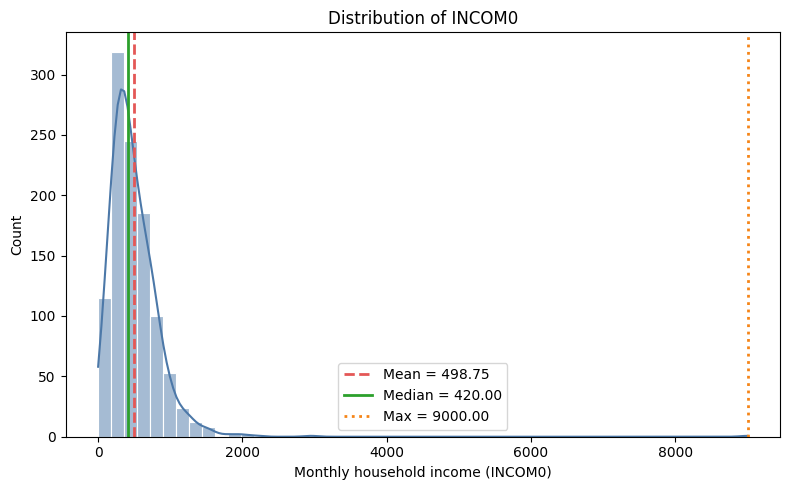

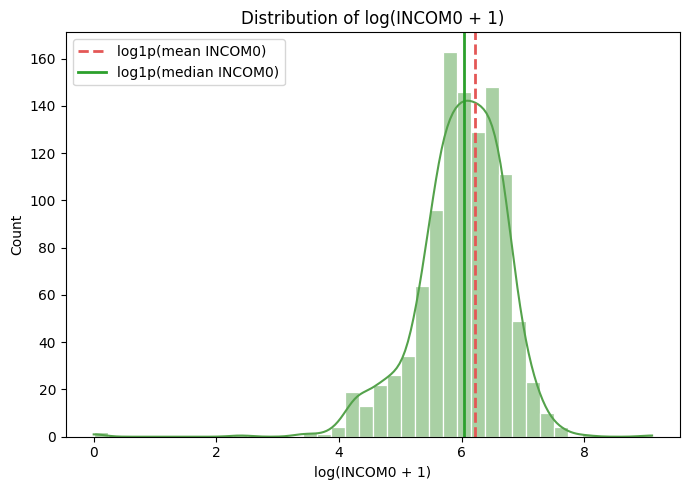

In [9]:
# INCOM0 분포 시각화: 우측 편의와 고소득 꼬리 확인
incom0_dist = adt["INCOM0"].dropna()

incom0_mean = incom0_dist.mean()
incom0_median = incom0_dist.median()
incom0_max = incom0_dist.max()

incom0_summary = pd.DataFrame({
    "variable": ["INCOM0"],
    "n": [len(incom0_dist)],
    "mean": [incom0_mean],
    "median": [incom0_median],
    "std": [incom0_dist.std()],
    "min": [incom0_dist.min()],
    "p25": [incom0_dist.quantile(0.25)],
    "p75": [incom0_dist.quantile(0.75)],
    "max": [incom0_max],
})
display(incom0_summary.round(2))

plt.figure(figsize=(8, 5))
sns.histplot(incom0_dist, bins=50, kde=True, color="#4C78A8", edgecolor="white")
plt.axvline(incom0_mean, color="#E45756", linestyle="--", linewidth=2, label=f"Mean = {incom0_mean:.2f}")
plt.axvline(incom0_median, color="#2CA02C", linestyle="-", linewidth=2, label=f"Median = {incom0_median:.2f}")
plt.axvline(incom0_max, color="#F58518", linestyle=":", linewidth=2, label=f"Max = {incom0_max:.2f}")
plt.title("Distribution of INCOM0")
plt.xlabel("Monthly household income (INCOM0)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# 로그 변환 후 분포: 회귀분석에서 log_INCOM0를 사용한 이유를 보조적으로 확인
plt.figure(figsize=(7, 5))
sns.histplot(np.log1p(incom0_dist), bins=40, kde=True, color="#54A24B", edgecolor="white")
plt.axvline(np.log1p(incom0_mean), color="#E45756", linestyle="--", linewidth=2, label="log1p(mean INCOM0)")
plt.axvline(np.log1p(incom0_median), color="#2CA02C", linestyle="-", linewidth=2, label="log1p(median INCOM0)")
plt.title("Distribution of log(INCOM0 + 1)")
plt.xlabel("log(INCOM0 + 1)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()
